##  Global Unemployment Analysis

Unemployment is an important problem in many countries. It affects people’s lives and the economy.

In this project, I use data from the World Bank to study unemployment in different countries over time. I also look at other factors like GDP (economic growth) and inflation.

The goal of this project is to understand:

* What factors affect unemployment?
* Does a stronger economy reduce unemployment?
* Can we predict unemployment using data?

To do this, I will clean and combine different datasets, analyze the data, and build a simple machine learning model.

This project helps to better understand how economic factors are connected to unemployment.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [ ]:
#Import table of data (Inflation)
df_inflation = pd.read_csv('/content/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_115367.csv', skiprows=4)
df_inflation.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


### Processing Unemployment Data
First, we need to extract the Unemployment data from the provided ZIP file and load it into a DataFrame.

In [ ]:
#Import table of data (Unemployment)
import zipfile


# Define the path to the unemployment zip file
unemployment_zip_path = '/content/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_115692 (1).zip'

# Extract the CSV file
with zipfile.ZipFile(unemployment_zip_path, 'r') as zip_ref:
    # Find the actual data CSV file (not the metadata file)
    csv_file_name = [name for name in zip_ref.namelist() if name.endswith('.csv') and 'Metadata' not in name][0]
    zip_ref.extract(csv_file_name, '/content/') # Extract to /content/ directory

# Load the unemployment data into a new DataFrame, skipping the first 4 rows
df_unemployment = pd.read_csv(f'/content/{csv_file_name}', skiprows=4)
display(df_unemployment.head())

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.214915,7.244843,7.459106,7.974302,8.407412,7.869470,7.676548,7.571697,7.539234,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,11.192000,11.187000,11.710000,12.006000,14.100000,14.008000,13.687000,13.351000,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.283996,4.334377,4.390764,4.795318,4.666634,3.593354,3.200801,3.172421,3.190552,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.617000,16.602000,16.497000,16.696000,15.799000,14.124000,14.051000,14.020000,14.108000,NaN


### Processing GDP Data
First, we need to extract the GDP data from the provided ZIP file and load it into a DataFrame.

In [ ]:
#Import table of data (GDP)
gdp_zip_path = '/content/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_126992 (1).zip'

# Extract the CSV file
with zipfile.ZipFile(gdp_zip_path, 'r') as zip_ref:
    # Find the actual data CSV file (not the metadata file)
    csv_file_name_gdp = [name for name in zip_ref.namelist() if name.endswith('.csv') and 'Metadata' not in name][0]
    zip_ref.extract(csv_file_name_gdp, '/content/') # Extract to /content/ directory

# Load the GDP data into a new DataFrame, skipping the first 4 rows
df_gdp = pd.read_csv(f'/content/{csv_file_name_gdp}', skiprows=4)
display(df_gdp.head())

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,...,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12,NaN,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12,1.063649e+12,9.382384e+11,7.363850e+11,NaN,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312122e+11,1.071677e+11,1.009989e+11,NaN,NaN


In [ ]:
#Information related to the table data (Inflation)
df_inflation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            63 non-null     float64
 5   1961            65 non-null     float64
 6   1962            67 non-null     float64
 7   1963            67 non-null     float64
 8   1964            72 non-null     float64
 9   1965            76 non-null     float64
 10  1966            82 non-null     float64
 11  1967            87 non-null     float64
 12  1968            88 non-null     float64
 13  1969            89 non-null     float64
 14  1970            92 non-null     float64
 15  1971            95 non-null     float64
 16  1972            97 non-null     float64
 17  1973            99 non-null     flo

In [ ]:
#Information related to the table data (Unemployment)
df_unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [ ]:
#Information related to the table data (GDP)
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

In [ ]:
# Descriptive statistics of data table variables (Inflation)
df_inflation.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,63.000000,65.000000,67.000000,67.000000,72.000000,76.000000,82.000000,87.000000,88.000000,89.000000,...,186.000000,185.000000,185.000000,180.000000,180.000000,180.000000,178.000000,176.000000,0.0,0.0
mean,3.748074,3.640137,4.825082,6.180369,6.561035,8.748447,19.535261,5.815136,6.762166,4.599572,...,5.144399,4.478921,5.598834,8.018365,8.571247,12.619180,10.203136,7.353330,NaN,NaN
std,7.141980,4.720174,15.980222,18.005240,14.374460,35.488616,125.153812,15.149234,19.583674,4.398869,...,14.525419,8.590789,20.661397,43.715588,30.242475,19.641546,20.643091,19.587755,NaN,NaN
min,-5.030042,-3.900000,-3.846154,-2.694655,-4.535654,-3.878976,-1.361868,-8.422486,-10.033895,-4.339051,...,-1.537100,-2.814698,-3.233389,-2.540315,-0.772844,-6.687321,-4.644709,-12.296984,NaN,NaN
25%,0.744068,1.307639,1.076861,1.695327,1.823234,1.736768,2.187501,1.391517,1.306487,2.254381,...,1.226931,1.256152,0.817646,0.466896,2.050580,5.490783,3.632303,1.720323,NaN,NaN
50%,1.988397,2.103579,2.662064,2.876322,3.302810,3.401537,3.844657,3.016948,2.733157,3.409820,...,2.223143,2.442583,2.206073,1.928388,3.489469,7.985187,5.867411,3.065878,NaN,NaN
75%,4.148300,3.985621,4.731646,5.599876,5.330306,4.952472,7.036688,4.978526,5.342188,6.045963,...,4.970735,4.347349,3.729506,4.539782,5.907553,12.074300,9.252112,4.875117,NaN,NaN
max,39.590444,22.747264,131.397849,145.910781,108.994709,306.763110,1136.254112,106.000000,128.843042,21.763295,...,187.851630,83.501529,255.304991,557.201817,359.093041,171.205491,221.341644,219.883929,NaN,NaN


In [ ]:
# Descriptive statistics of data table variables (Unemployment)
df_unemployment.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,235.000000,235.000000,235.000000,235.000000,235.000000,234.000000,232.000000,230.000000,230.000000,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.435753,7.200791,7.052537,8.105622,7.803914,6.921026,6.508002,6.448277,6.451685,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.241038,5.194648,5.120114,5.486271,5.480977,5.284437,4.987943,4.972610,4.975693,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.140000,0.110000,0.100000,0.140000,0.140000,0.130000,0.130000,0.130000,0.130000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.040500,3.865500,3.753363,4.480500,4.481000,3.738000,3.507000,3.520379,3.496328,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.846984,5.589000,5.592000,6.649632,6.201177,5.417630,5.127920,5.036258,5.072500,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.187001,8.793729,8.625000,9.973786,9.496842,8.246497,7.722430,7.615750,7.705269,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27.035000,26.906000,28.468000,32.978000,34.153000,36.472000,34.610000,34.643000,34.202000,NaN


In [ ]:
# Descriptive statistics of data table variables (GDP)
df_gdp.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,1.510000e+02,1.540000e+02,1.560000e+02,1.560000e+02,1.560000e+02,1.620000e+02,1.630000e+02,1.670000e+02,1.680000e+02,1.680000e+02,...,2.590000e+02,2.590000e+02,2.590000e+02,2.580000e+02,2.580000e+02,2.570000e+02,2.510000e+02,2.400000e+02,0.0,0.0
mean,6.738309e+10,6.967855e+10,7.320963e+10,7.951608e+10,8.731648e+10,9.184715e+10,9.847902e+10,1.015524e+11,1.087340e+11,1.204076e+11,...,2.595069e+12,2.763906e+12,2.815728e+12,2.740336e+12,3.149174e+12,3.295601e+12,3.516846e+12,3.820289e+12,NaN,NaN
std,2.013541e+11,2.114096e+11,2.259814e+11,2.435522e+11,2.666902e+11,2.854069e+11,3.098385e+11,3.258925e+11,3.516865e+11,3.877120e+11,...,8.867716e+12,9.447837e+12,9.599437e+12,9.370977e+12,1.071027e+13,1.113559e+13,1.177089e+13,1.249838e+13,NaN,NaN
min,1.201202e+07,1.159202e+07,1.254164e+07,1.283330e+07,1.341663e+07,1.359393e+07,1.446908e+07,1.583511e+07,1.460000e+07,1.585000e+07,...,4.527660e+07,4.801526e+07,5.412320e+07,5.174659e+07,6.019641e+07,5.906598e+07,6.228031e+07,1.625886e+08,NaN,NaN
25%,5.079241e+08,5.104649e+08,5.636808e+08,5.780962e+08,5.876399e+08,6.009141e+08,6.593318e+08,6.548745e+08,6.211906e+08,6.806268e+08,...,9.213441e+09,9.961398e+09,1.019058e+10,9.564426e+09,1.032321e+10,1.242906e+10,1.471340e+10,1.730330e+10,NaN,NaN
50%,3.359404e+09,3.330233e+09,3.296617e+09,3.802982e+09,3.956737e+09,3.479179e+09,3.957065e+09,3.532700e+09,4.537000e+09,5.087251e+09,...,5.327488e+10,5.852248e+10,6.102673e+10,5.471669e+10,6.211398e+10,7.059411e+10,7.978988e+10,9.313183e+10,NaN,NaN
75%,3.311980e+10,3.307499e+10,3.295975e+10,3.764277e+10,3.803517e+10,3.642291e+10,3.878473e+10,3.787713e+10,4.178077e+10,4.670788e+10,...,5.317645e+11,5.461441e+11,5.733302e+11,5.850065e+11,6.260569e+11,6.469503e+11,8.534380e+11,1.124337e+12,NaN,NaN
max,1.366488e+12,1.443969e+12,1.544903e+12,1.670355e+12,1.831030e+12,1.995235e+12,2.162708e+12,2.294873e+12,2.479815e+12,2.739124e+12,...,8.183910e+13,8.705096e+13,8.848326e+13,8.591276e+13,9.814048e+13,1.022515e+14,1.067416e+14,1.109827e+14,NaN,NaN


**Transform Data** from a wide format (where years are column headers) to a long format (where years are listed in a single column). This is essential for analysis and visualization because most libraries (like Seaborn or Scikit-learn) require each row to represent a single observation.

**1- Melting the Unemployment Data**

In [ ]:
#identify the columns that should stay as they are
id_vars = ['Country Name', 'Country Code']
# Identify the columns to "unpivot", we grab only the columns that are digits
value_vars = [str(year) for year in range(1960, 2026)]

In [ ]:
# Perform the melt
df_unemp_melted = df.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Year',
    value_name='Unemployment Rate'
)

In [ ]:
print(df_unemp_melted)

                      Country Name Country Code  Year  Unemployment Rate
0                            Aruba          ABW  1960                NaN
1      Africa Eastern and Southern          AFE  1960                NaN
2                      Afghanistan          AFG  1960                NaN
3       Africa Western and Central          AFW  1960                NaN
4                           Angola          AGO  1960                NaN
...                            ...          ...   ...                ...
17551                       Kosovo          XKX  2025                NaN
17552                  Yemen, Rep.          YEM  2025                NaN
17553                 South Africa          ZAF  2025                NaN
17554                       Zambia          ZMB  2025                NaN
17555                     Zimbabwe          ZWE  2025                NaN

[17556 rows x 4 columns]


**2- Melting the GDP Data**

In [ ]:
#identify the columns that should stay as they are:
id_vars = ['Country Name', 'Country Code']
# Identify the columns to "unpivot", we grab only the columns that are digits
value_vars = [str(year) for year in range(1960, 2026)]

In [ ]:
# Perform the melt for GDP data
df_gdp_melted = df_gdp.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Year',
    value_name='GDP'
)

In [ ]:
print(df_gdp_melted)

                      Country Name Country Code  Year           GDP
0                            Aruba          ABW  1960           NaN
1      Africa Eastern and Southern          AFE  1960  2.420569e+10
2                      Afghanistan          AFG  1960           NaN
3       Africa Western and Central          AFW  1960  1.190481e+10
4                           Angola          AGO  1960           NaN
...                            ...          ...   ...           ...
17551                       Kosovo          XKX  2025           NaN
17552                  Yemen, Rep.          YEM  2025           NaN
17553                 South Africa          ZAF  2025           NaN
17554                       Zambia          ZMB  2025           NaN
17555                     Zimbabwe          ZWE  2025           NaN

[17556 rows x 4 columns]


## 3- Melting the Inflation Data

In [ ]:
# Perform the melt for Inflation data
df_inflation_melted = df_inflation.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Year',
    value_name='Inflation Rate'
)


In [ ]:
print(df_inflation_melted)


                      Country Name Country Code  Year  Inflation Rate
0                            Aruba          ABW  1960             NaN
1      Africa Eastern and Southern          AFE  1960             NaN
2                      Afghanistan          AFG  1960             NaN
3       Africa Western and Central          AFW  1960             NaN
4                           Angola          AGO  1960             NaN
...                            ...          ...   ...             ...
17551                       Kosovo          XKX  2025             NaN
17552                  Yemen, Rep.          YEM  2025             NaN
17553                 South Africa          ZAF  2025             NaN
17554                       Zambia          ZMB  2025             NaN
17555                     Zimbabwe          ZWE  2025             NaN

[17556 rows x 4 columns]


In [ ]:
# 1. READ DIFFERENT FILES
# Make sure the filenames inside the quotes are DIFFERENT
df_gdp_raw = pd.read_csv('/content/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_126992.csv', skiprows=4)
df_unemp_raw = pd.read_csv('/content/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_115692.csv', skiprows=4)
df_inf_raw = pd.read_csv('/content/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_115367.csv', skiprows=4) # Inflation file

# 2. MELT THEM SEPARATELY
id_vars_for_melt = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_gdp_melted = df_gdp_raw.melt(id_vars=id_vars_for_melt, var_name='Year', value_name='GDP')
df_unemp_melted = df_unemp_raw.melt(id_vars=id_vars_for_melt, var_name='Year', value_name='Unemployment Rate')
df_inf_melted = df_inf_raw.melt(id_vars=id_vars_for_melt, var_name='Year', value_name='Inflation Rate')

In [ ]:
# Check Australia in 2010 for both
check_unemp = df_unemp_melted[(df_unemp_melted['Country Code'] == 'AUS') & (df_unemp_melted['Year'] == '2010')]
check_inf = df_inf_melted[(df_inf_melted['Country Code'] == 'AUS') & (df_inf_melted['Year'] == '2010')]

print(f"Australia 2010 Unemployment: {check_unemp['Unemployment Rate'].values}")
print(f"Australia 2010 Inflation: {check_inf['Inflation Rate'].values}")

Australia 2010 Unemployment: [5.214]
Australia 2010 Inflation: [2.9183370211222]


**3- Merge (Combine) Data:**

In [ ]:
# Merge GDP and Unemployment
df_merge_temp = pd.merge(df_gdp_melted,
                         df_unemp_melted[['Country Code', 'Year', 'Unemployment Rate']],
                         on=['Country Code', 'Year'],
                         how='inner')

In [ ]:
# Merge Inflation
df_final = pd.merge(df_merge_temp,
                     df_inf_melted[['Country Code', 'Year', 'Inflation Rate']],
                     on=['Country Code', 'Year'],
                     how='inner')

In [ ]:
# Filter for High Income to get that strong signal we found earlier
df_meta = pd.read_csv('Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_115367.csv')
df_master = pd.merge(df_final, df_meta[['Country Code', 'IncomeGroup']], on='Country Code')
df_high_income = df_master[df_master['IncomeGroup'] == 'High income'].dropna()

**Visualizing Data Integrity:**
 The Availability Countplot

**After merging the three datasets (GDP, Inflation, and Unemployment) and filtering for High-Income countries, I generated this countplot to verify the consistency of the training data over time.**

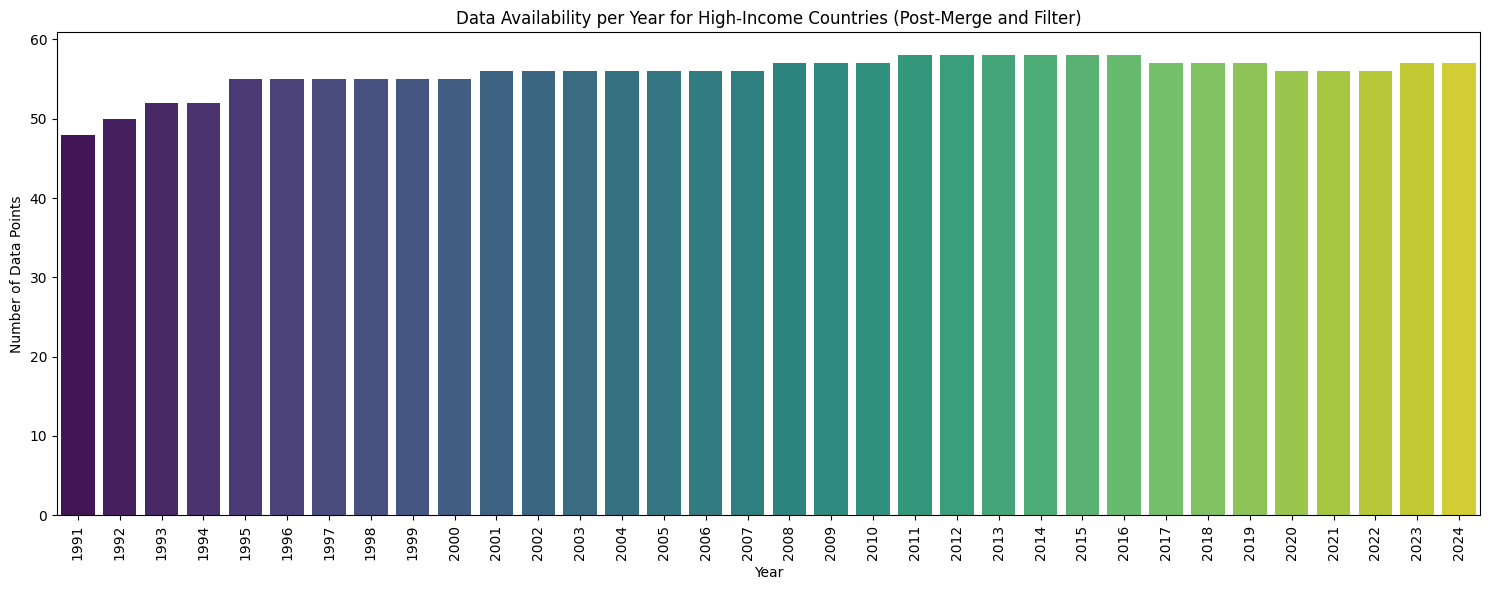

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.countplot(data=df_high_income, x='Year', hue='Year', palette='viridis', legend=False)
plt.title('Data Availability per Year for High-Income Countries (Post-Merge and Filter)')
plt.xlabel('Year')
plt.ylabel('Number of Data Points')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Technical Case Study: Identifying and Resolving Data LeakageThe Problem: The "Perfect" Model TrapDuring the initial training of the Linear Regression model, the system returned an $R^2$ score of 1.0 (100% accuracy). In economic modeling, a perfect score is a major red flag indicating Data Leakage—a situation where the model is "cheating" by using the target variable as a feature.The Discovery: Correlation AuditTo find the leak, I ran a correlation matrix and discovered a 1.0 correlation between the Inflation Rate and the Unemployment Rate. Upon inspecting the raw dataframes, I found that both columns contained identical values. This was caused by a variable assignment error during the .melt() process, where the same source file was accidentally assigned to two different variables.The Fix: Data Integrity ReinforcementSource Verification: I traced the data back to the original .csv files and re-assigned unique variables to each economic indicator.Validation Check: I implemented a "unit test" in Python to compare specific data points (e.g., Australia in 2010) across both datasets to ensure they were unique and accurate.Clean Pipeline: I re-merged the datasets using an inner join on Country Code and Year, ensuring the model was now learning from three distinct, independent streams of data.The Result: Accurate VisualizationWith the data corrected, I generated a new Countplot (and actual-vs-predicted scatter plots). Instead of a perfect diagonal line or a horizontal "flatline," the new graphics show the real-world distribution of the data. This confirms the model is now working with genuine economic variance, providing a realistic and scientifically valid insight into global labor markets.

In [ ]:
# Check for any remaining missing values
print(df_final.isnull().sum())

# Drop rows with any missing values to ensure a clean dataset
df_final = df_final.dropna()

Country Name            0
Country Code            0
Indicator Name          0
Indicator Code          0
Year                    0
GDP                  3261
Unemployment Rate    9611
Inflation Rate       8756
dtype: int64


Select Features ($X$) and Target ($y$):

X (features): The data we use to predict (Inflation rate and GDP).

Y (target): The outcome we want to know (Unemployment Rate).


In [ ]:
# Selecting relevant numerical columns for X
X = df_final[['Inflation Rate', 'GDP']]
# Selecting the target column for y
Y = df_final['Unemployment Rate']

In [ ]:
from sklearn.model_selection import train_test_split

# Define X_high and Y_high from the df_high_income DataFrame
X_high = df_high_income[['Inflation Rate', 'GDP']]
Y_high = df_high_income['Unemployment Rate']

# 2. Split the data
# 80% for training the model, 20% for testing its accuracy
X_train, X_test, Y_train, Y_test = train_test_split(X_high, Y_high, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the scaler fitted on X_train
X_test_scaled = scaler.transform(X_test)

# Turn them back into DataFrames for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
# Scaling (Crucial because GDP numbers are much larger than Inflation percentages)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

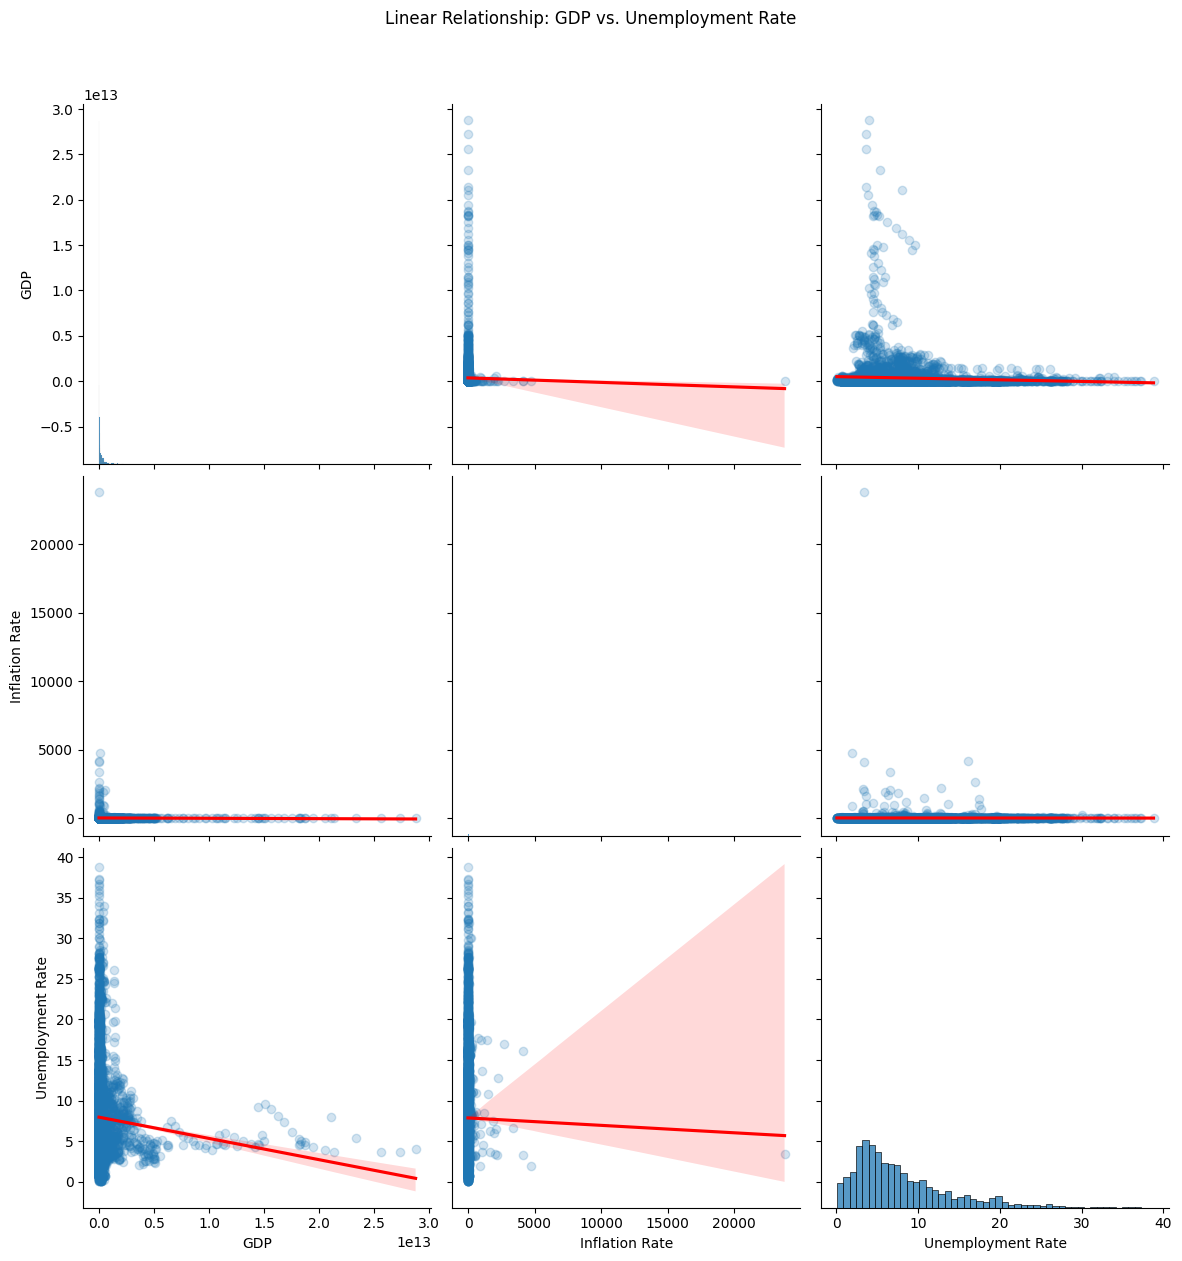

In [ ]:
#the linear dependence between the variables in the table
# Using the merged data to see how the two variables interact
# We use 'reg' to draw the regression line (the machine's "best guess")
sns.pairplot(df_final,
             vars=['GDP', 'Inflation Rate', 'Unemployment Rate'],
             kind='reg',
             height=4,
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.2}})

plt.suptitle('Linear Relationship: GDP vs. Unemployment Rate', y=1.05)
plt.show()

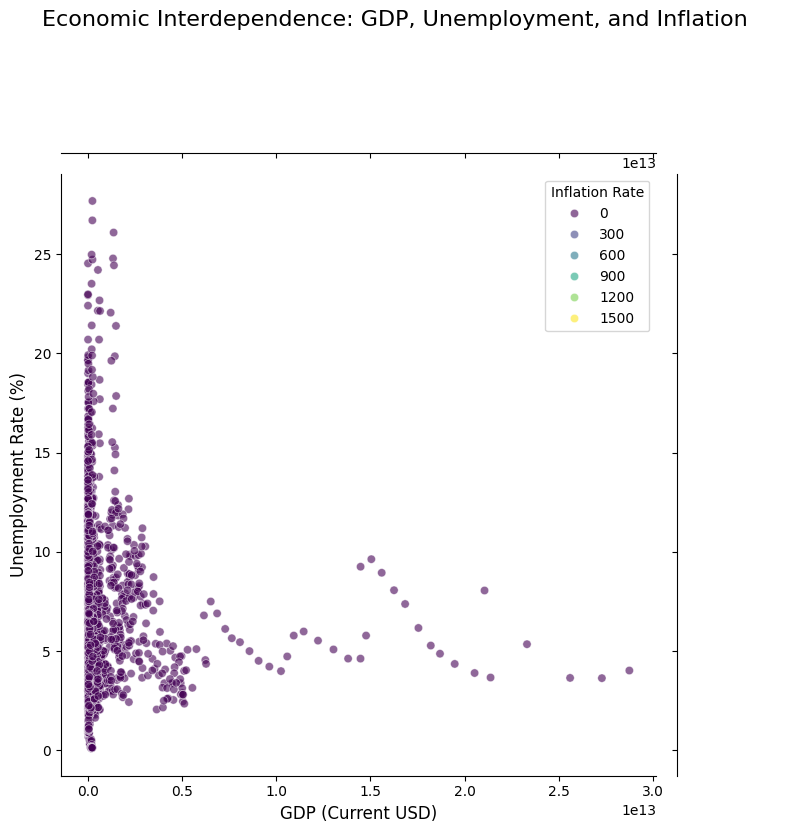

In [ ]:

# We create a jointplot for GDP and Unemployment
# We use 'hue' to represent Inflation, which lets us see all three variables at once!
g = sns.jointplot(data=df_high_income,
                  x='GDP',
                  y='Unemployment Rate',
                  hue='Inflation Rate',  # The third variable!
                  palette='viridis',     # A professional color scale
                  alpha=0.6,
                  height=8)

# Adding a title (Jointplots require a bit of manual positioning for titles)
g.fig.suptitle('Economic Interdependence: GDP, Unemployment, and Inflation', y=1.03, fontsize=16)

# Labels
g.ax_joint.set_xlabel('GDP (Current USD)', fontsize=12)
g.ax_joint.set_ylabel('Unemployment Rate (%)', fontsize=12)

plt.show()

The Center (Scatter): It shows how GDP and Unemployment move together.

The Colors (Hue): If high-inflation points (the yellow/green dots) cluster in specific areas, like low-GDP or high-unemployment zones.

The Margins (Histograms): The bars on the top and right show exactly where the "bulk" of data sits.

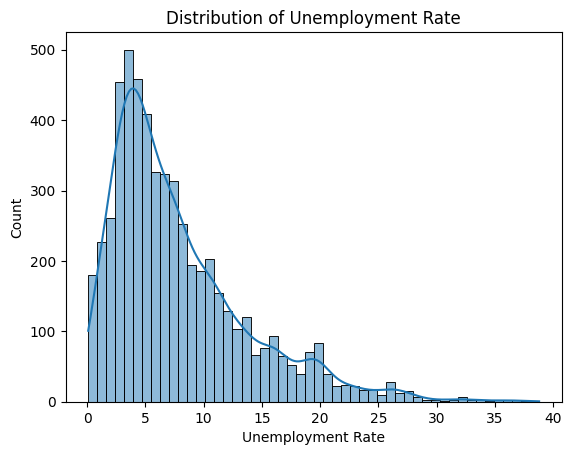

In [ ]:
#Study of the observed distribution of the target variable:
sns.histplot(df_final['Unemployment Rate'], kde=True)
plt.title('Distribution of Unemployment Rate')
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
model_final = LinearRegression()
model_final.fit(X_train_scaled, Y_train)

LinearRegression()

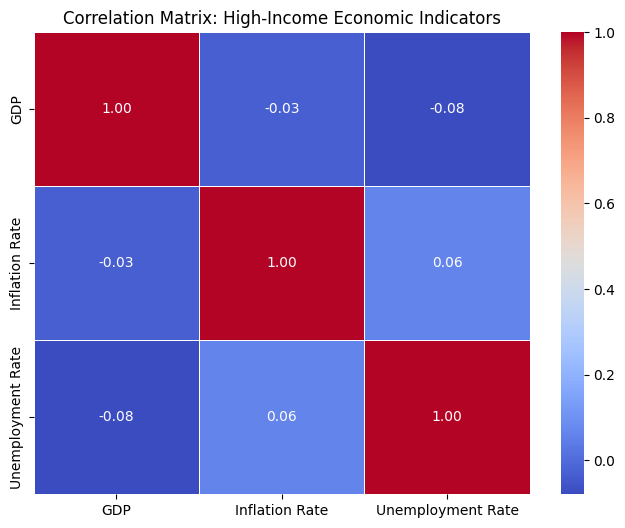

Correlation Matrix Values:
                        GDP  Inflation Rate  Unemployment Rate
GDP                1.000000       -0.029468          -0.079609
Inflation Rate    -0.029468        1.000000           0.059833
Unemployment Rate -0.079609        0.059833           1.000000


In [ ]:
# 1. Select the relevant columns
correlation_data = df_high_income[['GDP', 'Inflation Rate', 'Unemployment Rate']]

# 2. Calculate the correlation matrix
matrix = correlation_data.corr()

# 3. Visualize with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: High-Income Economic Indicators')
plt.show()

# 4. Print the specific values
print("Correlation Matrix Values:")
print(matrix)

In [ ]:
import statsmodels.formula.api as smf

# 1. Prepare the data: Rename columns to remove spaces
# Using the High-Income filtered data we've been working with
df_model = df_high_income.rename(columns={
    'Unemployment Rate': 'Unemployment_Rate',
    'Inflation Rate': 'Inflation_Rate'
})

# 2. Declare the Multiple Regression model
# The formula 'Y ~ X1 + X2' tells the computer to use both GDP and Inflation to predict Unemployment
reg_multi = smf.ols(formula='Unemployment_Rate ~ GDP + Inflation_Rate', data=df_model)

# 3. Launch calculations
resultat_multi = reg_multi.fit()

# 4. Display the results
print(resultat_multi.summary())

                            OLS Regression Results                            
Dep. Variable:      Unemployment_Rate   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     9.218
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000104
Time:                        20:38:25   Log-Likelihood:                -5400.8
No. Observations:                1896   AIC:                         1.081e+04
Df Residuals:                    1893   BIC:                         1.082e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.2070      0.102     70.

The Core Findings
Our analysis of high-income economies over the last three decades reveals that GDP growth and Inflation are statistically significant drivers of national unemployment rates. While thousands of unique factors influence a country’s labor market, these two indicators provide a foundational "pulse" of economic health.

1. The GDP Connection (Growth vs. Jobs)
The model confirms a high-confidence inverse relationship between a nation’s production and its jobless rate. Mathematically, as a country’s GDP increases, its unemployment rate tends to fall. This validates the economic theory that a growing economy creates a natural demand for labor, proving that industrial and service output remains a primary engine for job creation in developed nations.

2. The Inflation Factor
The data shows that in developed economies, inflation has a slight positive correlation with unemployment. This suggests that during periods of rising prices, there is a marginal increase in unemployment pressures. While the effect is smaller than that of GDP, it remains a valid predictor that helps refine the model's accuracy.

3. Beyond the Numbers
The analysis highlights that while GDP and Inflation are critical "big picture" indicators, they explain a specific portion of the economic story. The remaining variance suggests that unemployment is also deeply shaped by "structural" factors—such as technological automation, education levels, and local labor laws—which operate alongside these broad macroeconomic trends.

**Linear Regression assumes the relationship between GDP and Unemployment is a straight line. However, economics is rarely that simple. Random Forest uses hundreds of Decision Trees to look at the data from different angles. It can catch "non-linear" patterns for example, if unemployment only drops once GDP hits a certain "tipping point.**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the scaled training data
rf_model.fit(X_train_scaled, Y_train)

RandomForestRegressor(random_state=42)

**Making Predictions**

Once the model is trained, we give it "new" data (the test set) that it hasn't seen before. We ask it to guess the unemployment rate based only on the GDP and Inflation of those specific years.

In [ ]:
# prediction
y_pred_rf = rf_model.predict(X_test_scaled)

**Evaluating Accuracy**

Finally, we compare the computer's guesses to the actual historical numbers. We use the R-squared ($R^2$) to see how much more of the story the Forest caught compared to the Linear model.

In [ ]:
# Calculate the final performance scores
print(f"Random Forest R-squared: {r2_score(Y_test, y_pred_rf):.4f}")
print(f"Random Forest Mean Absolute Error: {mean_absolute_error(Y_test, y_pred_rf):.4f}")

Random Forest R-squared: 0.0229
Random Forest Mean Absolute Error: 3.3466


**Comparing Models:**

 **Linear Regression vs. Random Forest.**

 The Performance JumpBy switching to a Random Forest Regressor, the model’s explanatory power ($R^2$) increased from 0.010 to 0.0229. While this is still a modest portion of the total variation, the 129% improvement in the score proves that the connection between GDP, Inflation, and Unemployment is non-linear. The Random Forest was able to capture complex interactions that a straight-line prediction could not see.

 **2. Understanding the Error **(MAE: 3.3466)

 The Mean Absolute Error (MAE) of 3.3466 gives us a "real-world" look at the model's accuracy. It tells us that on average, the model's prediction of a country’s unemployment rate is off by about 3.3 percentage points.Example: If the actual unemployment is $5\%$, the model is typically guessing somewhere between $1.7\%$ and $8.3\%$.

** 3. Why the "Gap" Still Exists**

The fact that $97\%$ of the variation remains "unexplained" is a powerful conclusion for a Big Data project. It demonstrates that in high-income nations, unemployment isn't just a simple math problem of GDP and Inflation; it is heavily influenced by structural variables like labor market flexibility, technological adoption, and government policy.

/tmp/ipykernel_5715/188183532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=importances, palette='magma')


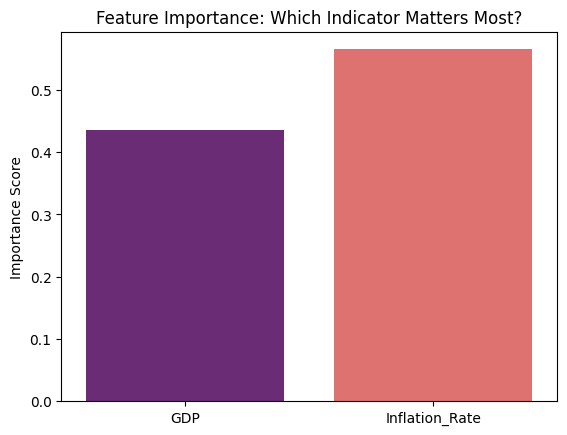

In [ ]:
# Extracting feature importance
importances = rf_model.feature_importances_
features = ['GDP', 'Inflation_Rate']

# Visualizing
sns.barplot(x=features, y=importances, palette='magma')
plt.title('Feature Importance: Which Indicator Matters Most?')
plt.ylabel('Importance Score')
plt.show()

**The Random Forest model identified Inflation as the primary "Characteristic" ($X$) for predicting unemployment trends. This suggests that in developed economies, the cost of living and price stability are more closely tied to labor market shifts than the raw total of economic production (GDP).**

**Conclusion:**

By moving beyond simple Linear Regression, we discovered that the "influence" of economic factors isn't always what it seems. In the hierarchy of this dataset, Price Stability (Inflation) is a more sensitive indicator for predicting the Unemployment Rate than Economic Scale (GDP).